In [1]:
import numpy as np
import matplotlib.pyplot as plt
import RF_Track as rft
from scipy.optimize import minimize, curve_fit
from CLEAR_line import *
from partrec_gaussian_optimiser_utils import partrec_gaussian_optimiser_utils
from topasToDose import getDosemap
from uniformity_fit import *
from partrec_foil_plotting import partrec_foil_plotting
from RF_track_utils import *
from flatness import *


RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [1]:
def supergaussian1D(x, A, x0, sigma_x, P):
    return A * np.exp(-( (x-x0)**2 /(2*sigma_x**2) )**P)
    
def r90(sig,P):
    return sig * np.sqrt(2) * (-np.log(0.9))**(1/(2*P))

#80% of central beam
def mask80(x):
    cdf = np.cumsum(x, dtype=float)
    cdf /= cdf[-1] # Normalize CDF to 1
    mask = (cdf >= 0.1) & (cdf <= 0.9) # Mask for central 80%
    return x[mask]

def moving_average(x):
    n = int(len(x)/10)
    """Simple moving average with window size n."""
    return np.convolve(x, np.ones(n)/n, mode='same')

def get_s2_params(max_radius, max_thickness, N_slices, convolution_factor):
    s2_sigma = max_radius / 2
    step = max_radius / N_slices

    # Radial positions
    x = np.arange(-(max_radius + step), 0, step=step)

    # Thickness profile
    y = norm.pdf(x, 0, s2_sigma * convolution_factor)
    y = y - np.min(y)
    y *= max_thickness / np.max(y)
    # plt.scatter(x, y)
    slice_widths = np.diff(y) #thicknesses of each slice in L
    slice_radii = np.abs(x[1:])   # Corresponding radii (height)

    return slice_radii, slice_widths

def sum_2gaussians(x, A, x0, sigma_x):
    return A * (np.exp(-( (x-x0)**2 /(2*sigma_x**2) )) + np.exp(-( (x+x0)**2 /(2*sigma_x**2) )) )

def flatness(x):
    
    x = moving_average(x) #smoothing
    x = mask80(x)
    return (max(x)-min(x))/ (max(x)+min(x))

def plot_phsp(T,M, n_bins=50,fov=200,title=''):
     
    def scatter_hist(x, y, ax, ax_histx, ax_histy):
        
        ax_histx.tick_params(axis="x", labelbottom=True)
        ax_histy.tick_params(axis="y", labelleft=True)

        # the scatter plot:
        ax.scatter(x, y,s=1,alpha=0.5)
        ax.set_xlim(-fov,fov)
        ax.set_ylim(-fov,fov)

        ax.set_xlabel('X (mm)')  # Set x-axis label for scatter plot
        ax.set_ylabel('Y (mm)')

        slice_width = 1
        phsp_xslice = M[(M[:,2] < slice_width)]
        phsp_xslice = phsp_xslice[(phsp_xslice[:,2] > -slice_width)]
        
        phsp_yslice = M[(M[:,0] < slice_width)]
        phsp_yslice = phsp_yslice[(phsp_yslice[:,0] > -slice_width)]

        
        hist_x, bin_edges_x = np.histogram(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov])
        bin_centers_x = (bin_edges_x[:-1] + bin_edges_x[1:]) / 2


        hist_y, bin_edges_y = np.histogram(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov])
        bin_centers_y = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2

        #fits
        p0=[np.max(hist_x),  np.mean(phsp_xslice[:,0]), np.std(phsp_xslice[:,0]), 4]
        params_x, _ = curve_fit(supergaussian1D, bin_centers_x, hist_x, p0=p0)

        params_y, _ = curve_fit(supergaussian1D, bin_centers_y, hist_y, p0=p0)
        xy_fit_curve = np.linspace(-fov, fov, 500)
       
        sig_x,sig_y, P_x, P_y = params_x[2], params_y[2], params_x[3], params_y[3]
        r90_x, r90_y = r90(sig_x, P_x), r90(sig_y, P_y)
    
        # Plot SuperGaussian fits

        ax_histx.hist(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov], color="b",alpha=0.6,label= ' X-Intensity')
        ax_histx.plot(xy_fit_curve, supergaussian1D(xy_fit_curve, *params_x), 'r-', label=f"SuperGaussian Fit (P={params_x[3]:.2f},r90={r90_x:.2f})")
        ax_histx.plot(bin_centers_x, moving_average(hist_x), 'k-', label=f'Smoothed (F={flatness(hist_x):.3f})')
        ax_histx.legend()


        

        ax_histy.hist(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov], color="b",alpha=0.6,label= ' Y-Intensity',orientation="horizontal")
        ax_histy.plot(supergaussian1D(xy_fit_curve, *params_y), xy_fit_curve,  'r-', label=f"SuperGaussian Fit (P={params_y[3]:.2f},r90={r90_x:.2f})")
        ax_histy.plot(moving_average(hist_y),bin_centers_y, 'k-', label=f'Smoothed (F={flatness(hist_y):.3f})')
        ax_histy.legend()

    fig, axs = plt.subplot_mosaic([['histx', '.'],
                                ['scatter', 'histy']],
                                figsize=(10, 8),
                                width_ratios=(4, 1), height_ratios=(1, 4),
                                layout='constrained')
    fig.suptitle(title)
    scatter_hist(M[:,0], M[:,2], axs['scatter'], axs['histx'], axs['histy'])
    plt.show()


from sklearn.neighbors import NearestNeighbors

def nearest_neighbor_test(x,y):
    points = np.array([x,y]).T
    nbrs = NearestNeighbors(n_neighbors=2).fit(points)
    distances, _ = nbrs.kneighbors(points)
    nn_distances = distances[:, 1]  # skip self-distance

    mean_dist = nn_distances.mean()
    std_dist = nn_distances.std()
    print(nn_distances)
    cv = std_dist / mean_dist  
    # coefficient of variation = 0.52 is poisson uniform, <0.52 is too uniform, >0.52 clustering

    return mean_dist, std_dist, cv

def mask2d(x,y):
    r = np.sqrt(x**2 + y**2)
    threshold = np.percentile(r, 60)
    mask = r <= threshold
    return x[mask],y[mask]


In [3]:

mass = RF_Track.electronmass    # particle mass in MeV/c^2
population = 10 * RF_Track.nC               # number of particles per bunch                         # particle charge in e units
P_ref = 198  
N_particles = int(500000)
charge = -1


            # reference bunch



In [ ]:
start = 'CA.QFD0350' #'CA.ACS0270S_MECH'
end = 'CA.DHJ0840' #'CA.STLINE$END'
Twiss = RF_Track.Bunch6d_twiss()

quad_currents = np.array([11,32,22,19,39.4,18,54.5,94.3,4,0,0]) # k1 values from OPTIMISE_CLEAR.py, last two quads not in selection

# #HUG last year
# Twiss.beta_x = 17.7        # m
# Twiss.beta_y = 13.9     # m
# Twiss.alpha_x = -1.14 
# Twiss.alpha_y = 0.359
# Twiss.emitt_x = 4.62     # mm.mrad normalised emittance
# Twiss.emitt_y = 3.86     # mm.mrad
# # Twiss.sigma_t = 10 * RF_Track.ps       # mm/c   or 37 * RF_Track.ps
# # Twiss.sigma_pt = 10     # permille
# Twiss.mean_xp = 0.0
# Twiss.mean_yp = 0.0

# #start of year

# Twiss.beta_x = 10 # m
# Twiss.beta_y = 7.9# m
# Twiss.alpha_x = -0.7
# Twiss.alpha_y = -0.4
# Twiss.emitt_x = 12.6 # mm.mrad normalised emittance
# Twiss.emitt_y = 19

quad_currents = np.array([11,32,22,19,32,18,0,0,0,0,0]) #from new flat setting
quad_currents = np.array([11,32,22,19,32,18,1.1,44.5,47,0,0])  # optimised 
Twiss.beta_x = 47.8 # m
Twiss.beta_y = 35 # m
Twiss.alpha_x = -4.7
Twiss.alpha_y = -4
Twiss.emitt_x = 6.8 # mm.mrad normalised emittance
Twiss.emitt_y = 12

# FLASH single bunch
Twiss.beta_x = 55 # m
Twiss.beta_y = 30.4 # m
Twiss.alpha_x = -5.5
Twiss.alpha_y = -3.38
Twiss.emitt_x = 12.8# mm.mrad normalised emittance
Twiss.emitt_y = 20

# CONV
# Twiss.beta_x = 18.3 # m
# Twiss.beta_y = 10.9 # m
# Twiss.alpha_x = -1.83
# Twiss.alpha_y = -1.26
# Twiss.emitt_x = 2 # mm.mrad normalised emittance
# Twiss.emitt_y = 3.5


B0 = RF_Track.Bunch6d_QR(mass, population, charge, P_ref, Twiss, N_particles)    

# for s1_l in [0.1]: #np.linspace(0.01,5,5):
#     for s2_width in [1.6]: #np.linspace(0.01,10,5):
#         for s2_depth in [2.43]: #np.linspace(0.01,10,5):

#             '''params dimensions in mm'''
#             CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start, end, P_ref, quad_currents)
#             CLEAR_lattice.append(rft.Drift(0.084))
#             # S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
#             # # S1 = rft.Absorber(s1_l/1000,'air')
#             # S1.disable_energy_straggling()
#             # S1.set_shape ('circular', 1,1  )
#             # CLEAR_lattice.append(S1)

#             CLEAR_lattice.append(rft.Drift(0.532))  #drift to S2

#             # s2_r,s2_l = get_s2_params(s2_width, s2_depth, 4, 1)

#             # for i in range(len(s2_l)):
#             #     Slice = rft.Absorber(s2_l[i]/1000,31.9, 37, 288.31,1.32,-1) #changed from 37
#             #     Slice.disable_energy_straggling()
#             #     Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
#             #     CLEAR_lattice.append(Slice)

#             # CLEAR_lattice.append(rft.Drift(2.024))  #drift to window


#             B1 = CLEAR_lattice.track(B0)
#             T = CLEAR_lattice.get_transport_table(
#             '%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')[-1]
#             M = B1.get_phase_space('%x %xp %y %yp %E %z')
#             masked_x, masked_y = mask2d(M[:,0],M[:,2])
#             transmission_5mm = np.sum(masked_x**2 + masked_y**2 < 5**2) / len(masked_x)
#             title = 's1_l={}mm, s2_width={:.2f}mm, s2_depth={:.2f}mm, transmission_5mm={:.2f}'.format(s1_l, s2_width, s2_depth, transmission_5mm)
#             plot_phsp(T,M,120,15,title=title)

#             #plot phase space
#             plt.figure()
#             plt.scatter(M[:,0], M[:,1], s=1, alpha=0.5)
#             plt.xlabel('X (mm)')
#             plt.ylabel('X\' (mrad)')
#             plt.title(f'X-X\' Phase Space, sig={T[5]:.2f} mm emitt={Twiss.emitt_x:.2f} mm.mrad, beta={T[1]:.2f} m, alpha={T[3]:.2f}')

#             plt.figure()
#             plt.scatter(M[:,2], M[:,3], s=1, alpha=0.5)
#             plt.xlabel('Y (mm)')
#             plt.ylabel('Y\' (mrad)')
#             plt.title(f'Y-Y\' Phase Space, sig={T[6]:.2f} mm emitt={Twiss.emitt_y:.2f} mm.mrad, beta={T[2]:.2f} m, alpha={T[4]:.2f}')

In [7]:

merit_beam_Uniform(B1, 5, 0.5)

141084 500000
1.5742916890671717 0.0 0.04745078022400001 5


1.6217424692911717

In [ ]:
len(T[:,1])

9

In [17]:
T[7],T[8]

(0.37138503698825637, 0.09152234361201321)

In [18]:
quad_currents = np.array([11,32,22,19,32,18,1.1,44.5,47,0,0])
CLEAR_lattice_to_810 = get_beamline("CLEAR_Beamline_Survey.txt",start, "CA.BTV0810", P_ref, quad_currents)
B1 = CLEAR_lattice_to_810.track(B0)
T = CLEAR_lattice_to_810.get_transport_table(
            '%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')[-1]
print("beam size at 810:", T[5], T[6], "beta at 810:", T[1], T[2], "alpha at 810:", T[3], T[4], "divergence at 810:", T[7], T[8])

beam size at 810: 0.8798412876590502 0.5675597396524305 beta at 810: 23.433863114935612 6.240772461343455 alpha at 810: 9.840864977484753 -0.11297390917475085 divergence at 810: 0.37138503698825637 0.09152234361201321


In [ ]:
from scipy.optimize import curve_fit

def parabola(x, A, B, C):
    return A * x**2 + B * x + C


def fit_parabola_to_spot_size(scan_values, spot_sizes_mm, label=""):
    """
    Fits spot_size^2 = A*x^2 + B*x + C.

    scan_values can be current [A] or quadrupole strength k [m^-2].
    spot_sizes_mm must be RMS spot size in mm.
    """

    scan_values = np.asarray(scan_values, dtype=float)
    spot_sizes_mm = np.asarray(spot_sizes_mm, dtype=float)

    valid = np.isfinite(scan_values) & np.isfinite(spot_sizes_mm)

    x = scan_values[valid]
    sigma_mm = spot_sizes_mm[valid]

    # Fit sigma^2, not sigma
    sigma2_mm2 = sigma_mm**2

    popt, pcov = curve_fit(parabola, x, sigma2_mm2)
    A, B, C = popt

    x_fit = np.linspace(np.min(x), np.max(x), 300)
    sigma2_fit = parabola(x_fit, A, B, C)

    # Avoid tiny negative numerical values before sqrt
    sigma_fit_mm = np.sqrt(np.maximum(sigma2_fit, 0.0))

    print(f"\n{label} parabola fit:")
    print(f"  sigma^2 = A*x^2 + B*x + C")
    print(f"  A = {A:.6e}")
    print(f"  B = {B:.6e}")
    print(f"  C = {C:.6e}")

    return {
        "A": A,
        "B": B,
        "C": C,
        "covariance": pcov,
        "x_fit": x_fit,
        "sigma_fit_mm": sigma_fit_mm,
        "sigma2_fit_mm2": sigma2_fit,
    }


tracking with current in QFD0760: 0 quad currents: [11, 32, 22, 19, 32, 18, 0, 0, 0, 0, 0]
sig_x at 875 from T: [2.80434337 1.11622343] sig_x from M: 2.804329343866931 sig_y from M: 1.116217852192515
tracking with current in QFD0760: 20 quad currents: [11, 32, 22, 19, 32, 18, 20, 0, 0, 0, 0]
sig_x at 875 from T: [6.5980563  1.02508157] sig_x from M: 6.598023314366852 sig_y from M: 1.0250764461111073
tracking with current in QFD0760: 40 quad currents: [11, 32, 22, 19, 32, 18, 40, 0, 0, 0, 0]
sig_x at 875 from T: [10.49897738  1.07014305] sig_x from M: 10.498924887536315 sig_y from M: 1.0701376982746573
tracking with current in QFD0760: 60 quad currents: [11, 32, 22, 19, 32, 18, 60, 0, 0, 0, 0]
sig_x at 875 from T: [14.50796129  1.22628651] sig_x from M: 14.50788874814582 sig_y from M: 1.2262803822403852
tracking with current in QFD0760: 80 quad currents: [11, 32, 22, 19, 32, 18, 80, 0, 0, 0, 0]
sig_x at 875 from T: [18.62614294  1.44995149] sig_x from M: 18.626049812522755 sig_y from M:

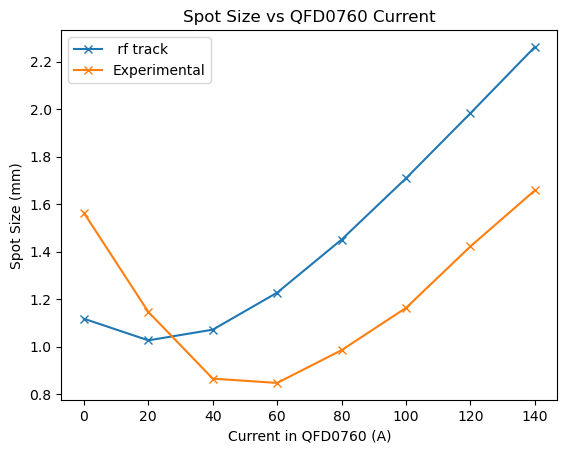

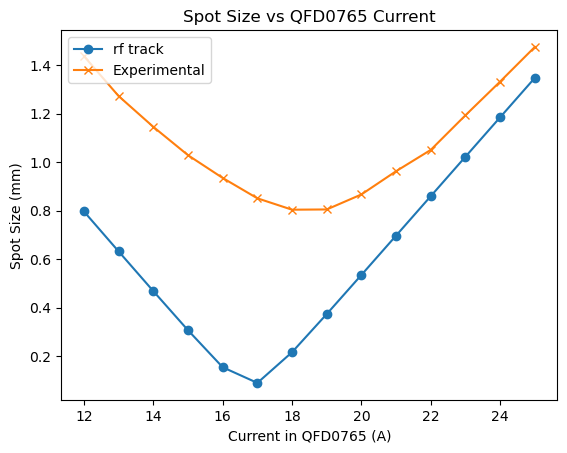

In [ ]:
#scan of 765 and look at beam size at 875 screen

#50 micron resolution add in quadrature.

quad_currents = np.array([11,32,22,19,32,18,0,0,0,0,0]) #from new flat setting
# FLASH single bunch
Twiss = RF_Track.Bunch6d_twiss()
Twiss.beta_x = 47.8 # m
Twiss.beta_y = 35 # m
Twiss.alpha_x = -4.7
Twiss.alpha_y = -4
Twiss.emitt_x = 6.8 # mm.mrad normalised emittance
Twiss.emitt_y = 12

#newest twiss 11may 5pm
Twiss.beta_x = 42.6 # m
Twiss.beta_y = 33.9 # m
Twiss.alpha_x = -4.74
Twiss.alpha_y = -4.36
Twiss.emitt_x = 17.3 # mm.mrad normalised emittance
Twiss.emitt_y = 25


B0 = RF_Track.Bunch6d_QR(mass, population, charge, P_ref, Twiss, 100000) 
currents_765_real =  np.arange(12,26,1)
spot_ysize765_real = [1.438, 1.273, 1.146, 1.029, 0.935, 0.851, 0.804, 0.805, 0.867, 0.963, 1.051, 1.194, 1.333, 1.476]
spot_ysize765_real_s1 = [np.nan, 1.637, 1.544, 1.473, 1.422, 1.388, 1.375, 1.380, 1.403, 1.442, 1.502, 1.565, 1.656, 1.773]

currents_760_real = np.arange(0,150,20)
spot_xsize760_real = [1.563, 1.146, 0.865, 0.847, 0.985, 1.163, 1.422, 1.658 ]
spot_xsize760_real_s1 = [1.765, 1.465, 1.308, 1.327, 1.420, 1.617, 1.914, 2.260]

spot_sizes_x = []
spot_sizes_y = []

for current760 in currents_760_real:
    CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start, end, P_ref, [11,32,22,19,32,18,current760,0,0,0,0])
    print("tracking with current in QFD0760:", current760, "quad currents:", [11,32,22,19,32,18,current760,0,0,0,0])
    CLEAR_lattice.append(rft.Drift(0.084))
    # S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
    # S1 = rft.Absorber(s1_l/1000,'air')
    # S1.disable_energy_straggling()
    # S1.set_shape ('circular', 1,1  )
    # CLEAR_lattice.append(S1)

    CLEAR_lattice.append(rft.Drift(0.532))  #drift to S2

    B1 = CLEAR_lattice.track(B0)
    T = CLEAR_lattice.get_transport_table(' %sigma_x %sigma_y')[-1]
    M = B1.get_phase_space('%x %xp %y %yp %E %z')
    print("sig_x at 875 from T:", T, "sig_x from M:", np.std(M[:,0]), "sig_y from M:", np.std(M[:,2]))
    spot_sizes_x.append(np.sqrt((np.std(M[:,2]))**2 + 0.05**2))

for current765 in currents_765_real:
    CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start,  end, P_ref, [11,32,22,19,32,18,0,current765,0,0,0])
    print("tracking with current in QFD0765:", current765, "quad currents:", [11,32,22,19,32,18,0,current765,0,0,0])
    CLEAR_lattice.append(rft.Drift(0.084))
    # S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
    # S1 = rft.Absorber(s1_l/1000,'air')
    # S1.disable_energy_straggling()
    # S1.set_shape ('circular', 1,1  )
    # CLEAR_lattice.append(S1)

    CLEAR_lattice.append(rft.Drift(0.532))  #drift to S2

    B1 = CLEAR_lattice.track(B0)
    T = CLEAR_lattice.get_transport_table(' %sigma_x %sigma_y')[-1]
    M = B1.get_phase_space('%x %xp %y %yp %E %z')
    print("sig_x at 875 from T:", T, "sig_x from M:", np.std(M[:,0]), "sig_y from M:", np.std(M[:,2]))
    # print("beam size at 875:", T)
    spot_sizes_y.append(np.sqrt((np.std(M[:,0]))**2 + 0.05**2)) #add 50 micron resolution in quadrature


plt.figure()
plt.plot(currents_760_real, spot_sizes_x, 'x-', label=' rf track')
plt.plot(currents_760_real, spot_xsize760_real, 'x-', label='Experimental')
plt.xlabel('Current in QFD0760 (A)')
plt.ylabel('Spot Size (mm)')
plt.title('Spot Size vs QFD0760 Current') 
plt.legend(loc=2)


plt.figure()
plt.plot(currents_765_real, spot_sizes_y, 'o-', label='rf track')
plt.plot(currents_765_real, spot_ysize765_real, 'x-', label='Experimental')
plt.xlabel('Current in QFD0765 (A)')
plt.ylabel('Spot Size (mm)')
plt.title('Spot Size vs QFD0765 Current') 
plt.legend(loc=2)

In [8]:
print(CLEAR_lattice.get_transport_table('%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')[0])
M = B0.get_phase_space('%x %xp %y %yp %E %z')
np.std(M[:,0]), np.std(M[:,2])

[ 0.         42.60064312 33.90494705 -4.73989659 -4.3605484   1.37914058
  1.47903669  0.15682584  0.19515826]


(1.3791336863634274, 1.4790292975117518)

In [27]:
CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start,  end, P_ref, [11,32,22,19,32,18,0,0,0,0,0])
CLEAR_lattice.append(rft.Drift(0.084))
# S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
# S1 = rft.Absorber(s1_l/1000,'air')
# S1.disable_energy_straggling()
# S1.set_shape ('circular', 1,1  )
# CLEAR_lattice.append(S1)

CLEAR_lattice.append(rft.Drift(0.532))  #drift to S2

B1 = CLEAR_lattice.track(B0)
T = CLEAR_lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')[-1]
T[6]

1.116223433323637

In [ ]:
from scipy.optimize import curve_fit

def parabola(k, A, B, C):
    return A * k**2 + B * k + C

def quad_scan_fit(k, sigma, d, l, sigma_units="m"):
    """
    Fit quadrupole scan data and return geometric emittance, beta, alpha.

    Parameters
    ----------
    k : array-like
        Quadrupole strength in m^-2.
    sigma : array-like
        RMS beam size at screen/SEM.
        Use RMS sigma, not FWHM. If you have FWHM, convert first:
        sigma = FWHM / 2.355
    d : float
        Drift distance from quadrupole to screen in m.
    l : float
        Effective quadrupole length in m.
    sigma_units : str
        "m" if sigma is in meters, "mm" if sigma is in millimeters.

    Returns
    -------
    dict with fit coefficients, sigma matrix, emittance, beta, alpha
    """

    k = np.asarray(k, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    if sigma_units == "mm":
        sigma = sigma * 1e-3
    elif sigma_units != "m":
        raise ValueError("sigma_units must be 'm' or 'mm'")

    # Fit sigma^2 vs k
    y = sigma**2
    popt, pcov = curve_fit(parabola, k, y)
    A, B, C = popt

    # Beam matrix at quadrupole
    sigma11 = A / (d**2 * l**2)
    sigma12 = (B - 2 * d * l * sigma11) / (2 * d**2 * l)
    sigma22 = (C - sigma11 - 2 * d * sigma12) / d**2

    det_sigma = sigma11 * sigma22 - sigma12**2

    if det_sigma <= 0:
        raise ValueError(
            f"Non-physical fit: determinant = {det_sigma:.3e}. "
            "Check units, RMS/FWHM conversion, k sign, or thin-lens assumptions."
        )

    emit = np.sqrt(det_sigma)
    beta = sigma11 / emit
    alpha = -sigma12 / emit
    gamma = sigma22 / emit

    return {
        "A": A,
        "B": B,
        "C": C,
        "covariance": pcov,
        "sigma11": sigma11,
        "sigma12": sigma12,
        "sigma22": sigma22,
        "emittance_geom_m_rad": emit,
        "emittance_geom_mm_mrad": emit * 1e6,
        "beta_m": beta,
        "alpha": alpha,
        "gamma_1_per_m": gamma,
    }

In [ ]:
d_760 = 3.87   #760 to 875
d_765 = 3.42 # 765 to 875
l = 0.226    # m, 

x_result = quad_scan_fit(currents_760_real, spot_xsize760_real, d=d, l=l, sigma_units="mm")
y_result = quad_scan_fit(currents_765_real, spot_ysize765_real, d=d, l=l, sigma_units="mm")

print("X plane rf track fit results:")
print("emittance [mm mrad]:", x_result["emittance_geom_mm_mrad"])
print("beta [m]:", x_result["beta_m"])
print("alpha:", x_result["alpha"])

# print("X plane experimental fit results:")
# print("emittance [mm mrad]:", x_result["emittance_geom_mm_mrad"])
# print("beta [m]:", x_result["beta_m"])
# print("alpha:", x_result["alpha"])

print("Y plane rf track fit results:")
print("emittance [mm mrad]:", y_result["emittance_geom_mm_mrad"])
print("beta [m]:", y_result["beta_m"])
print("alpha:", y_result["alpha"])

# print("Y plane experimental fit results:")
# print("emittance [mm mrad]:", y_result["emittance_geom_mm_mrad"])
# print("beta [m]:", y_result["beta_m"])
# print("alpha:", y_result["alpha"])

X plane rf track fit results:
emittance [mm mrad]: 0.001544237178055818
beta [m]: 0.09870263762397555
alpha: 1.437098106441312
Y plane rf track fit results:
emittance [mm mrad]: 0.014024599381965007
beta [m]: 1.0145687946908626
alpha: 4.353654227420774


In [ ]:
Twiss = RF_Track.Bunch6d_twiss()
start = 'CA.QFD0350' #'CA.ACS0270S_MECH'
end = 'CA.DHJ0840' #'CA.STLINE$END'
Twiss.beta_x = 42.6 # m
Twiss.beta_y = 33.9 # m
Twiss.alpha_x = -4.74
Twiss.alpha_y = -4.36
Twiss.emitt_x = 17.3 # mm.mrad normalised emittance
Twiss.emitt_y = 25
currents_765_real =  np.arange(12,26,1)
B0 = RF_Track.Bunch6d_QR(mass, population, charge, P_ref, Twiss, 100000)
for current in currents_765_real:
    CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start,  end, P_ref, [11,32,22,19,32,18,0,current,0,0,0])
    print("tracking with current in QFD0765:", current, "quad currents:", [11,32,22,19,32,18,0,current,0,0,0])
    CLEAR_lattice.append(rft.Drift(0.084)) #drift to S1
    CLEAR_lattice.append(rft.Drift(0.532))  #drift to S2

    B1 = CLEAR_lattice.track(B0)
    T = CLEAR_lattice.get_transport_table(
    '%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')[-1]
    M = B1.get_phase_space('%x %xp %y %yp %E %z')
    print("sig_x at 875 from T:", T[5], "sig_x from M:", np.std(M[:,0]), "sig_y from M:", np.std(M[:,2]))

tracking with current in QFD0765: 12 quad currents: [11, 32, 22, 19, 32, 18, 0, 12, 0, 0, 0]
sig_x at 875 from T: 0.7950240684177716 sig_x from M: 0.7950200932874917 sig_y from M: 1.3073362612463868
tracking with current in QFD0765: 13 quad currents: [11, 32, 22, 19, 32, 18, 0, 13, 0, 0, 0]
sig_x at 875 from T: 0.6297432145357654 sig_x from M: 0.6297400658118247 sig_y from M: 1.324264614308073
tracking with current in QFD0765: 14 quad currents: [11, 32, 22, 19, 32, 18, 0, 14, 0, 0, 0]
sig_x at 875 from T: 0.4652031494640611 sig_x from M: 0.46520082344250185 sig_y from M: 1.3413267439195833
tracking with current in QFD0765: 15 quad currents: [11, 32, 22, 19, 32, 18, 0, 15, 0, 0, 0]
sig_x at 875 from T: 0.30220452468628867 sig_x from M: 0.30220301365988583 sig_y from M: 1.3585189318244615
tracking with current in QFD0765: 16 quad currents: [11, 32, 22, 19, 32, 18, 0, 16, 0, 0, 0]
sig_x at 875 from T: 0.14515473447703645 sig_x from M: 0.1451540087015491 sig_y from M: 1.3758376107287715
tr